In [17]:
pip install mlxtend

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [18]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
#from sklearn.preprocessing import StandardScaler
from mlxtend.plotting import plot_decision_regions
df = pd.read_csv("FD.csv")
df.head()

,fault current,Type of fault
0,2.72,0
1,3.52,0
2,1.34,0
3,5.67,0
4,7.29,1


In [19]:
x = df[["fault current "]]
y = df["Type of fault "]
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.6666666666666666


In [20]:
for i in range(len(X_test)):
    print("Test data:", X_test.iloc[i], "| True label:", y_test.iloc[i])
if y_test.iloc[i] == y_pred[i]:
    print("Correct prediction")
else: 
    print("Wrong")

Test data: fault current     4.23
Name: 9, dtype: float64 | True label: 0
Test data: fault current     0.32
Name: 11, dtype: float64 | True label: 1
Test data: fault current     2.72
Name: 0, dtype: float64 | True label: 0
Correct prediction


In [21]:
FI = float(input("Enter the Fault Current: "))
predicted_label = knn.predict([[FI]])
print("Predicted label:", predicted_label[0])


Enter the Fault Current:  4.5


Predicted label: 0


C:\Users\visha\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


C:\Users\visha\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


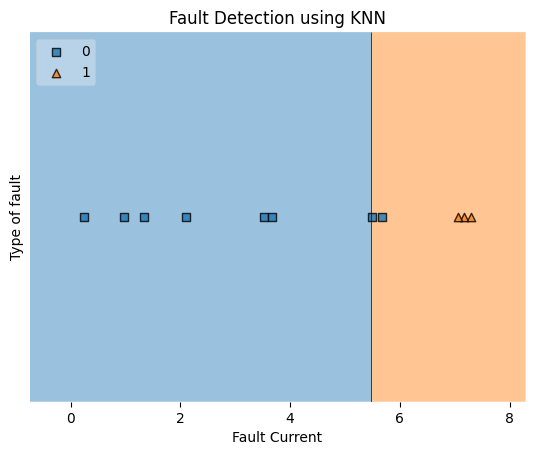

In [23]:
knn.fit(X_train, y_train)
plot_decision_regions(X_train.values, y_train.values, clf=knn, legend=2)
plt.xlabel('Fault Current')
plt.ylabel('Type of fault')
plt.title('Fault Detection using KNN')
plt.show()